In [1]:
from functools import partial
import numpy as np
import jax
import jax.numpy as jnp
from jax import vmap, jit
from jax_helpers import gg_space, glob_inh, sigmoid, softmax
from jax_scaffold_theta_bias import Scaffold_theta_bias, compute_sample_step, time_averaged_activation
#from jax_scaffold_thetah import Scaffold
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

In [2]:
lambdas = np.array([3, 4, 5])
lambdas_static = tuple(int(l) for l in lambdas)
scaffold = Scaffold_theta_bias(400, lambdas, 'sigmoid', gg_exc=5, gg_inh=-8.75, gamma=0.6, seed=0, dt=0.01)

g0_target = jnp.asarray(scaffold.grid)
h0        = jnp.asarray(scaffold.hc)
g0_init   = jnp.zeros_like(g0_target)
h0_norm   = jnp.linalg.norm(h0, axis=0)

def get_overlap(state, pattern):
    """Returns overlap between two states, vectorized"""
    return np.mean(state * pattern, axis=0)

def get_mutual_info(state, pattern):
    """Returns mutual information between two states, vectorized"""
    m = np.array(get_overlap(state, pattern))
    a, b = (1 + m)/2, (1 - m)/2
    s = a * np.log2(np.where(a > 0, a, 1)) + b* np.log2(np.where(b > 0, b, 1))
    return 1 + s
def sensory_weights(sensory, hc):
    N_patts = sensory.shape[1]
    hc_till_Npatts = hc[:, :N_patts]

    W_hs = hc_till_Npatts @ np.linalg.pinv(sensory)
    W_sh = sensory @ np.linalg.pinv(hc_till_Npatts)

    return W_hs, W_sh


# Plotting trajectories

In [6]:
freq, duty, phase = (0.5, 0.5), (0.0, 0.0), (0.0, 0.0)
n_steps = 1000
dt = 0.01
#scaffold = Scaffold(400, lambdas, 'sigmoid', gg_exc=1, gg_inh=-5, gamma=0.6)

g_traj, h_traj = Scaffold_theta_bias.simulate_run_traj(g0_init, h0,
                                      scaffold.weights, scaffold.lambdas, scaffold.tau_g, scaffold.tau_h,
                                      sigmoid, dt=dt, freq=freq, duty=duty, phase=phase, n_steps=n_steps,
                                      )

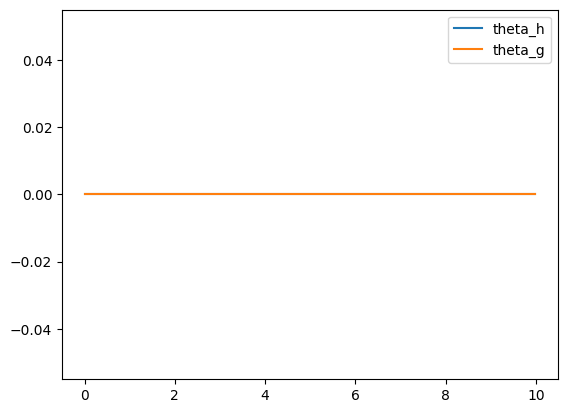

In [8]:
import numpy as np
import matplotlib.pyplot as plt
#freq, duty, phase = (0.2, 0.2), (0.5, 0.5), (0.0, 0.9)
def square_wave(t, freq, duty, phase_in_cycles):
        cycle_position = np.mod(freq * t - phase_in_cycles, 1.0)
        return np.where(cycle_position < duty, 1.0, 0.0)

t = np.arange(0, 10, dt)
plt.plot(t, square_wave(t, freq[0], duty[0], phase[0]), label='theta_h') #grid
plt.plot(t, square_wave(t, freq[1], duty[1], phase[1]), label='theta_g')  #hc
plt.legend()

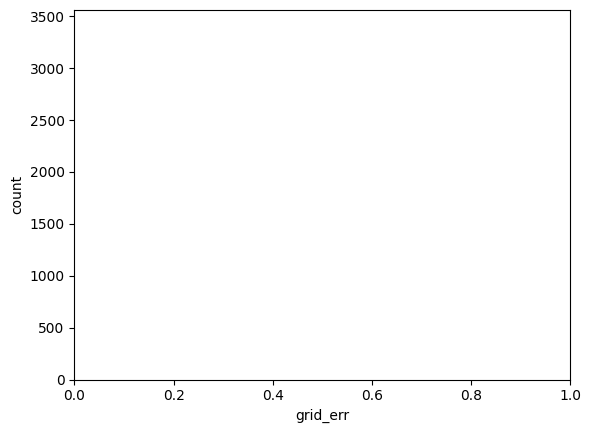

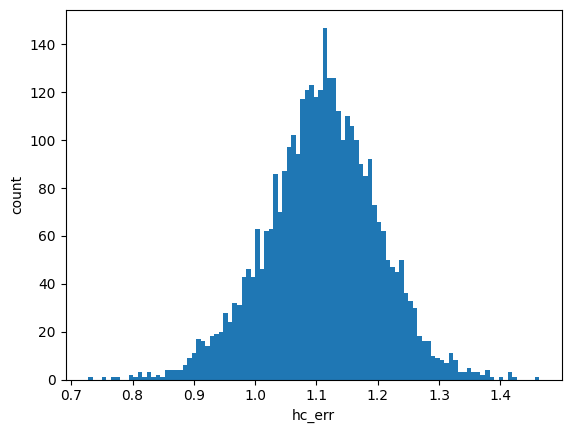

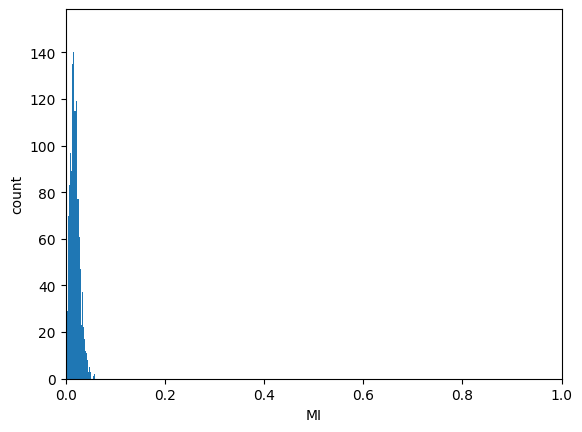

(50, 3600)


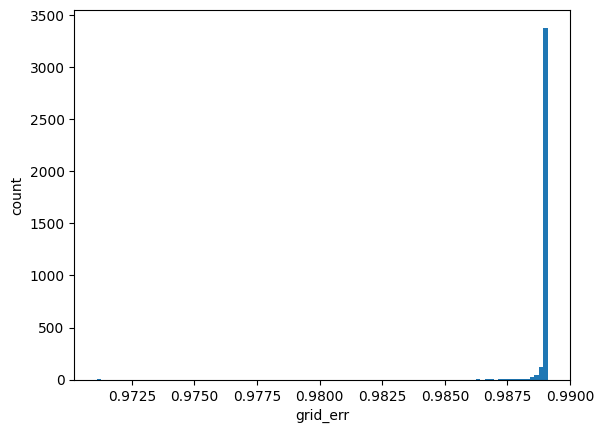

In [9]:
sample_step = compute_sample_step(freq[0], duty[0], phase[0], dt, n_steps)
g_err = np.max(np.abs(g_traj[sample_step, :, :] - g0_target), axis=0)
plt.hist(g_err.ravel(), bins=100)
plt.xlabel('grid_err'); plt.ylabel('count')
plt.xlim(0, 1)
plt.show()

sample_step_hc = compute_sample_step(freq[1], duty[1], phase[1], dt, n_steps)
hc_err = jnp.linalg.norm(h_traj[sample_step_hc, :, :] - h0[:, :], axis=0) / h0_norm
#time_avg_hc = time_averaged_activation(h_traj, 50)
#hc_err = jnp.linalg.norm(time_avg_hc - h0, axis=0) / h0_norm
plt.hist(hc_err.ravel(), bins=100)
#plt.xlim(0, 1)
plt.xlabel('hc_err'); plt.ylabel('count')
plt.show()

sens = np.sign(np.random.randn(3600, 3600))
W_hs, W_sh = sensory_weights(sens[:, :], h0)
s_actual = np.sign(W_sh @ h0)
s_recalled = np.sign(W_sh @ h_traj[sample_step_hc])
mi = get_mutual_info(s_recalled, s_actual)
plt.hist(mi, bins=100)
plt.xlim(0, 1)
plt.xlabel('MI'); plt.ylabel('count')
plt.show()

"""thresholds = np.linspace(0, 1, 50)
frac_vs_thresh = [np.mean(g_err < t) for t in thresholds]
plt.plot(thresholds, frac_vs_thresh)
plt.xlabel('threshold')
plt.ylabel('fraction recovered')
plt.show()"""

time_avg = time_averaged_activation(g_traj, 250)
print(time_avg.shape)
g_err_avg = np.max(np.abs(time_avg - g0_target), axis=0)
plt.hist(g_err_avg.ravel(), bins=100)
plt.xlabel('grid_err'); plt.ylabel('count')
plt.show()

799
fraction grid correct = 0.0
fraction hc correct = 0.0
overlap between sensory vectors: 0.15626968
MI between sensory vectors: 0.018967576


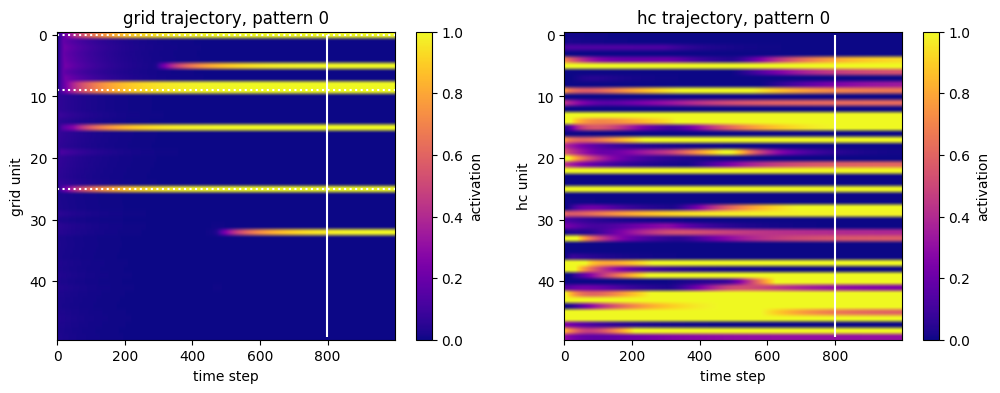

In [10]:
sample_step = compute_sample_step(freq[0], duty[0], phase[0], dt, n_steps)
print(sample_step)
#sample_step = compute_sample_step(0.2, 0.4, 0.0, scaffold.dt, 250)
sample_step_hc = compute_sample_step(freq[1], duty[1], phase[1], dt, n_steps)

g_err = np.max(np.abs(g_traj[sample_step, :, :] - g0_target), axis=0)
frac_grid_sig = np.mean(g_err < 0.3, axis=-1)
print('fraction grid correct =', frac_grid_sig)

hc_err = jnp.linalg.norm(h_traj[sample_step_hc, :, :] - h0[:, :], axis=0) / h0_norm
frac_hc_sig = np.mean(hc_err < 0.6, axis=-1)
print('fraction hc correct =', frac_hc_sig)

sens = np.sign(np.random.randn(3600, 3600))
s_actual = np.sign(W_sh @ h0)
s_recalled = np.sign(W_sh @ h_traj[sample_step_hc])
print("overlap between sensory vectors:", np.mean(get_overlap(s_recalled, s_actual)))
print("MI between sensory vectors:", np.mean(get_mutual_info(s_recalled, s_actual)))

patt = 0

# Get the indices for the horizontal lines
idx1 = np.argmax(g0_target[:, patt][:9])
idx2 = np.argmax(g0_target[:, patt][9:25]) + 9
idx3 = np.argmax(g0_target[:, patt][25:]) + 25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
im = ax1.imshow(np.asarray(g_traj[:, :, patt]).T, aspect='auto', origin='upper', cmap='plasma', vmin=0, vmax=1)
ax1.vlines(sample_step, 0, 49, colors='white')
ax1.hlines([idx1, idx2, idx3], 0, n_steps-1, colors='white', linestyles='dotted') # Add dotted horizontal lines
ax1.set_xlabel('time step')
ax1.set_ylabel('grid unit')
ax1.set_title(f'grid trajectory, pattern {patt}')
fig.colorbar(im, label='activation')

im = ax2.imshow(np.asarray(h_traj[:, :50, patt]).T, aspect='auto', origin='upper', cmap='plasma', vmin=0, vmax=1)
ax2.vlines(sample_step_hc, 0, 49, colors='white')
ax2.set_xlabel('time step')
ax2.set_ylabel('hc unit')
ax2.set_title(f'hc trajectory, pattern {patt}')
fig.colorbar(im, label='activation')
plt.show()

In [114]:
where = np.where(g_err > 0.6)
incorrect = g_traj[sample_step, :, where[0]]
print(where[0][:200])
print(get_mutual_info(np.sign(W_sh @ h0[:, 6]), np.sign(W_sh @ h_traj[sample_step_hc, :, 6])))
print(g_err[990])

[  0   1   3   4   5   6   8  10  11  12  14  17  18  19  21  22  23  24
  25  26  28  29  30  35  36  37  38  43  44  45  46  47  48  49  50  51
  54  55  56  60  61  64  65  66  69  71  72  73  74  75  76  78  83  85
  86  87  88  90  91  92  94  98  99 100 101 103 104 106 109 110 111 114
 115 117 118 119 124 125 126 128 129 130 131 132 135 136 138 142 144 145
 147 148 149 150 151 153 154 155 156 160 161 163 167 168 169 171 172 173
 175 176 177 178 179 181 182 185 186 187 188 189 190 192 193 194 196 197
 198 199 201 202 203 204 205 206 208 209 210 211 212 213 214 215 216 218
 219 220 222 223 224 225 226 227 228 230 231 233 234 235 236 237 238 240
 242 243 244 245 247 248 249 250 251 252 253 254 255 260 261 262 263 267
 268 269 270 271 272 273 274 276 279 280 281 285 286 287 288 293 294 296
 297 300]
0.00080162287
2.9802322e-07


# Freq, duty search (Only theta_h)

In [ ]:
freq_h_range = np.arange(0.0, 5.0, 0.1)
duty_h_range = np.arange(0.1, 1.1, 0.1)
FF, DD = np.meshgrid(freq_h_range, duty_h_range, indexing='ij')
freq_flat = jnp.asarray(FF.ravel())
duty_flat = jnp.asarray(DD.ravel())

vmapped_run = jax.jit(
    jax.vmap(
        Scaffold_theta_bias.simulate_run_sampled,
        in_axes=(None, None, None, None, None, None, None, None, None, (0, None), (0, None), (None, None), None),
        #         g0    h0  weights lambdas b  tau_g tau_h activation dt  freq       duty       phase      n_steps
    ),
    static_argnames=('lambdas', 'activation', 'n_steps'))

def score_thetah(weights, chunk_size=200, n_steps=250, dt=0.1):
    grid_chunks, hc_chunks = [], []
    n = freq_flat.shape[0]
    for start in tqdm(range(0, n, chunk_size)):
        f_chunk = freq_flat[start:start + chunk_size]
        d_chunk = duty_flat[start:start + chunk_size]

        g_sampled, h_sampled = vmapped_run(
            g0_init, h0, weights, lambdas_static,
            scaffold.b, scaffold.tau_g, scaffold.tau_h, sigmoid, dt,
            (f_chunk, 1.0), (d_chunk, 1.0), (0.0, 0.0), n_steps,
        )

        grid_err = jnp.max(jnp.abs(g_sampled - g0_target[None]), axis=1)          # (chunk, patts)
        hc_err   = jnp.linalg.norm(h_sampled - h0[None], axis=1) / h0_norm[None]  # (chunk, patts)

        grid_chunks.append(np.asarray(grid_err))
        hc_chunks.append(np.asarray(hc_err))

    grid_errors = np.concatenate(grid_chunks, axis=0).reshape(len(freq_h_range), len(duty_h_range), -1)
    hc_errors   = np.concatenate(hc_chunks, axis=0).reshape(len(freq_h_range), len(duty_h_range), -1)
    return grid_errors, hc_errors

In [ ]:
grid_errors, hc_errors = score_thetah(scaffold.weights)

100%|██████████| 3/3 [00:26<00:00,  8.73s/it]


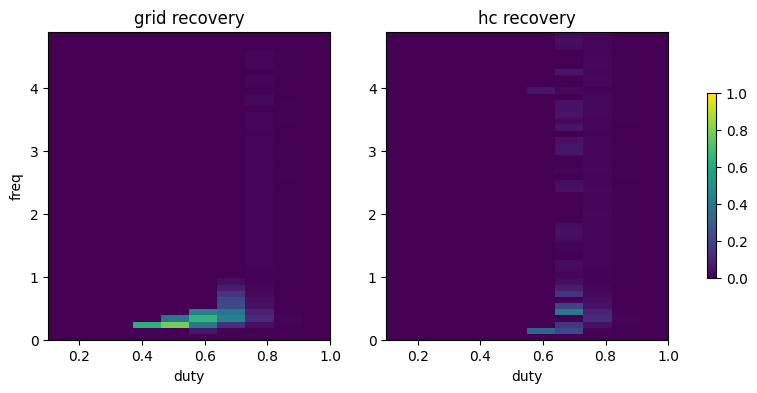

In [ ]:
frac_grid = np.mean(grid_errors < 0.2, axis=-1)
frac_hc   = np.mean(hc_errors < 0.4, axis=-1)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im0 = ax[0].imshow(frac_grid, origin='lower', vmin=0, vmax=1,
                    extent=[duty_h_range[0], duty_h_range[-1], freq_h_range[0], freq_h_range[-1]], aspect='auto')
ax[0].set_xlabel('duty'); ax[0].set_ylabel('freq'); ax[0].set_title('grid recovery')
im1 = ax[1].imshow(frac_hc, origin='lower', vmin=0, vmax=1,
                    extent=[duty_h_range[0], duty_h_range[-1], freq_h_range[0], freq_h_range[-1]], aspect='auto')
ax[1].set_xlabel('duty'); ax[1].set_title('hc recovery')
fig.colorbar(im1, ax=ax, shrink=0.6)

In [ ]:
flat_idx = np.argmax(frac_grid)
coords = np.unravel_index(flat_idx, frac_grid.shape)
print(coords)
print("Freq, duty for max grid recovery:", freq_h_range[coords[0]], duty_h_range[coords[1]])
print(np.max(frac_grid[1:, :-1]))

print(np.argmin(grid_errors[coords[0], coords[1], :]))

flat_idx = np.argmax(frac_hc)
coords = np.unravel_index(flat_idx, frac_hc.shape)
print(coords)
print("Freq, duty for max hc recovery:", freq_h_range[coords[0]], duty_h_range[coords[1]])
print(np.max(frac_hc[1:, :-1]))


(np.int64(2), np.int64(4))
Freq, duty for max grid recovery: 0.2 0.5
0.0019444444444444444 0.7825
3557
(np.int64(4), np.int64(6))
Freq, duty for max hc recovery: 0.4 0.7000000000000001
0.0019444444444444444 0.40166666666666667


# Parameter search (theta_h + theta_g)

In [11]:
def parameter_search_scored(scaffold, g0, h0, g_target, h_target, h_target_norm,
                             freq_h_vals, freq_g_vals, duty_h_vals, duty_g_vals,
                             phase_diff_vals, phase_h=0.0, n_steps=1000,
                             grid_thresh=0.3, hc_thresh=0.6, chunk_size=500, show_progress=True):

    grids = np.meshgrid(
        np.asarray(freq_h_vals), np.asarray(freq_g_vals),
        np.asarray(duty_h_vals), np.asarray(duty_g_vals),
        np.asarray(phase_diff_vals), indexing='ij',
    )
    param_shape = grids[0].shape
    freq_h_flat, freq_g_flat, duty_h_flat, duty_g_flat, phase_diff_flat = (
        jnp.asarray(g.ravel()) for g in grids
    )
    phase_g_flat = phase_h + phase_diff_flat

    g0, h0 = jnp.asarray(g0), jnp.asarray(h0)
    g_target, h_target = jnp.asarray(g_target), jnp.asarray(h_target)
    h_target_norm = jnp.asarray(h_target_norm)


    vmapped_run = jax.jit(
        jax.vmap(
            Scaffold_theta_bias.run_and_score,
            in_axes=(None, None, None, None, None, None, None, None,
                     (0, 0), (0, 0), (None, 0), None, None, None, None, None, None),
            #         g0    h0   weights lambdas  tau_g tau_h activation dt  freq    duty    phase       n_steps g_target h_target h_target_norm grid_thresh hc_thresh
        ),
        static_argnames=('lambdas', 'activation', 'n_steps'),
    )

    n = freq_h_flat.shape[0]
    grid_chunks, hc_chunks = [], []
    iterator = range(0, n, chunk_size)
    if show_progress:
        from tqdm import tqdm
        iterator = tqdm(iterator)

    for start in iterator:
        sl = slice(start, start + chunk_size)
        frac_grid_chunk, frac_hc_chunk = vmapped_run(
            g0, h0, scaffold.weights, scaffold.lambdas,
            scaffold.tau_g, scaffold.tau_h, scaffold.activation, 0.01,
            (freq_h_flat[sl], freq_g_flat[sl]),
            (duty_h_flat[sl], duty_g_flat[sl]),
            (phase_h, phase_g_flat[sl]),
            n_steps, g_target, h_target, h_target_norm, grid_thresh, hc_thresh,
        )
        grid_chunks.append(np.asarray(frac_grid_chunk))
        hc_chunks.append(np.asarray(frac_hc_chunk))

    frac_grid = np.concatenate(grid_chunks, axis=0).reshape(param_shape)
    frac_hc = np.concatenate(hc_chunks, axis=0).reshape(param_shape)
    return frac_grid, frac_hc


## 5D Search

In [12]:
freq_h_range = np.arange(0.5, 4.0, 0.5)
freq_g_range = np.arange(0.5, 4.0, 0.5)
duty_h_range = np.arange(0.0, 1.1, 0.1)
duty_g_range = np.arange(0.0, 1.1, 0.1)
phase_diff_range = np.arange(0.0, 1.1, 0.1)
phase_h = 0.0

In [ ]:
frac_grid, frac_hc = parameter_search_scored(
    scaffold, g0_init, h0, g0_target, h0, h0_norm,
    freq_h_range, freq_g_range, duty_h_range, duty_g_range, phase_diff_range,
    phase_h=phase_h,
    n_steps=1000, chunk_size=500,
)

np.save('frac_grid_output.npy', frac_grid)
np.save('frac_hc_output.npy', frac_hc)

# frac_grid_output: (Fh, Fg, Dh, Dg, Pd), frac_hc_output: (Fh, Fg, Dh, Dg, Pd)
print(frac_grid.shape, frac_hc.shape)

In [ ]:
frac_grid = np.load('frac_grid_2thetas.npy')
frac_hc = np.load('frac_hc_2thetas.npy')

In [ ]:
def best_params_by_phase(metric, freq_h_range, freq_g_range, duty_h_range, duty_g_range, phase_diff_range):
    rows = []
    for pi, phase_diff in enumerate(phase_diff_range):
        slab = metric[:, :, :, :, pi]                       # fix phase, keep the other 4 axes
        fh_i, fg_i, dh_i, dg_i = np.unravel_index(np.argmax(slab), slab.shape)
        rows.append({'freq_h': freq_h_range[fh_i], 'freq_g': freq_g_range[fg_i],
                     'duty_h': duty_h_range[dh_i], 'duty_g': duty_g_range[dg_i],
                     'phase_diff': phase_diff, 'score': float(slab[fh_i, fg_i, dh_i, dg_i])})
    return rows

rows = best_params_by_phase(frac_grid, freq_h_range, freq_g_range, duty_h_range, duty_g_range, phase_diff_range)
for row in sorted(rows, key=lambda x: x['score'], reverse=True):
    clean_row = {k: f'{v:.3f}' if isinstance(v, (np.float64, float)) else v for k, v in row.items()}
    print(clean_row)

{'freq_h': '0.000', 'freq_g': '3.750', 'duty_h': '0.200', 'duty_g': '0.600', 'phase_diff': '0.900', 'score': '0.591'}
{'freq_h': '0.000', 'freq_g': '3.500', 'duty_h': '0.200', 'duty_g': '0.600', 'phase_diff': '0.000', 'score': '0.591'}
{'freq_h': '0.000', 'freq_g': '3.500', 'duty_h': '0.200', 'duty_g': '0.600', 'phase_diff': '1.000', 'score': '0.591'}
{'freq_h': '0.000', 'freq_g': '3.750', 'duty_h': '0.200', 'duty_g': '0.600', 'phase_diff': '0.100', 'score': '0.589'}
{'freq_h': '0.000', 'freq_g': '3.750', 'duty_h': '0.200', 'duty_g': '0.600', 'phase_diff': '0.300', 'score': '0.589'}
{'freq_h': '0.000', 'freq_g': '3.500', 'duty_h': '0.200', 'duty_g': '0.600', 'phase_diff': '0.400', 'score': '0.589'}
{'freq_h': '0.000', 'freq_g': '3.250', 'duty_h': '0.200', 'duty_g': '0.600', 'phase_diff': '0.800', 'score': '0.588'}
{'freq_h': '0.000', 'freq_g': '3.750', 'duty_h': '0.200', 'duty_g': '0.600', 'phase_diff': '0.500', 'score': '0.588'}
{'freq_h': '0.000', 'freq_g': '3.750', 'duty_h': '0.200'

### Heatmaps of (Duty_h, Duty_g) for a Fixed Common Frequency

These heatmaps display the grid and head-direction cell recovery fractions for a specific common frequency (`freq_h` = `freq_g` = 1.25 Hz) across different combinations of `duty_h` and `duty_g`, separated by `phase_diff` values.


Generating heatmaps for common frequency: 2.5 Hz


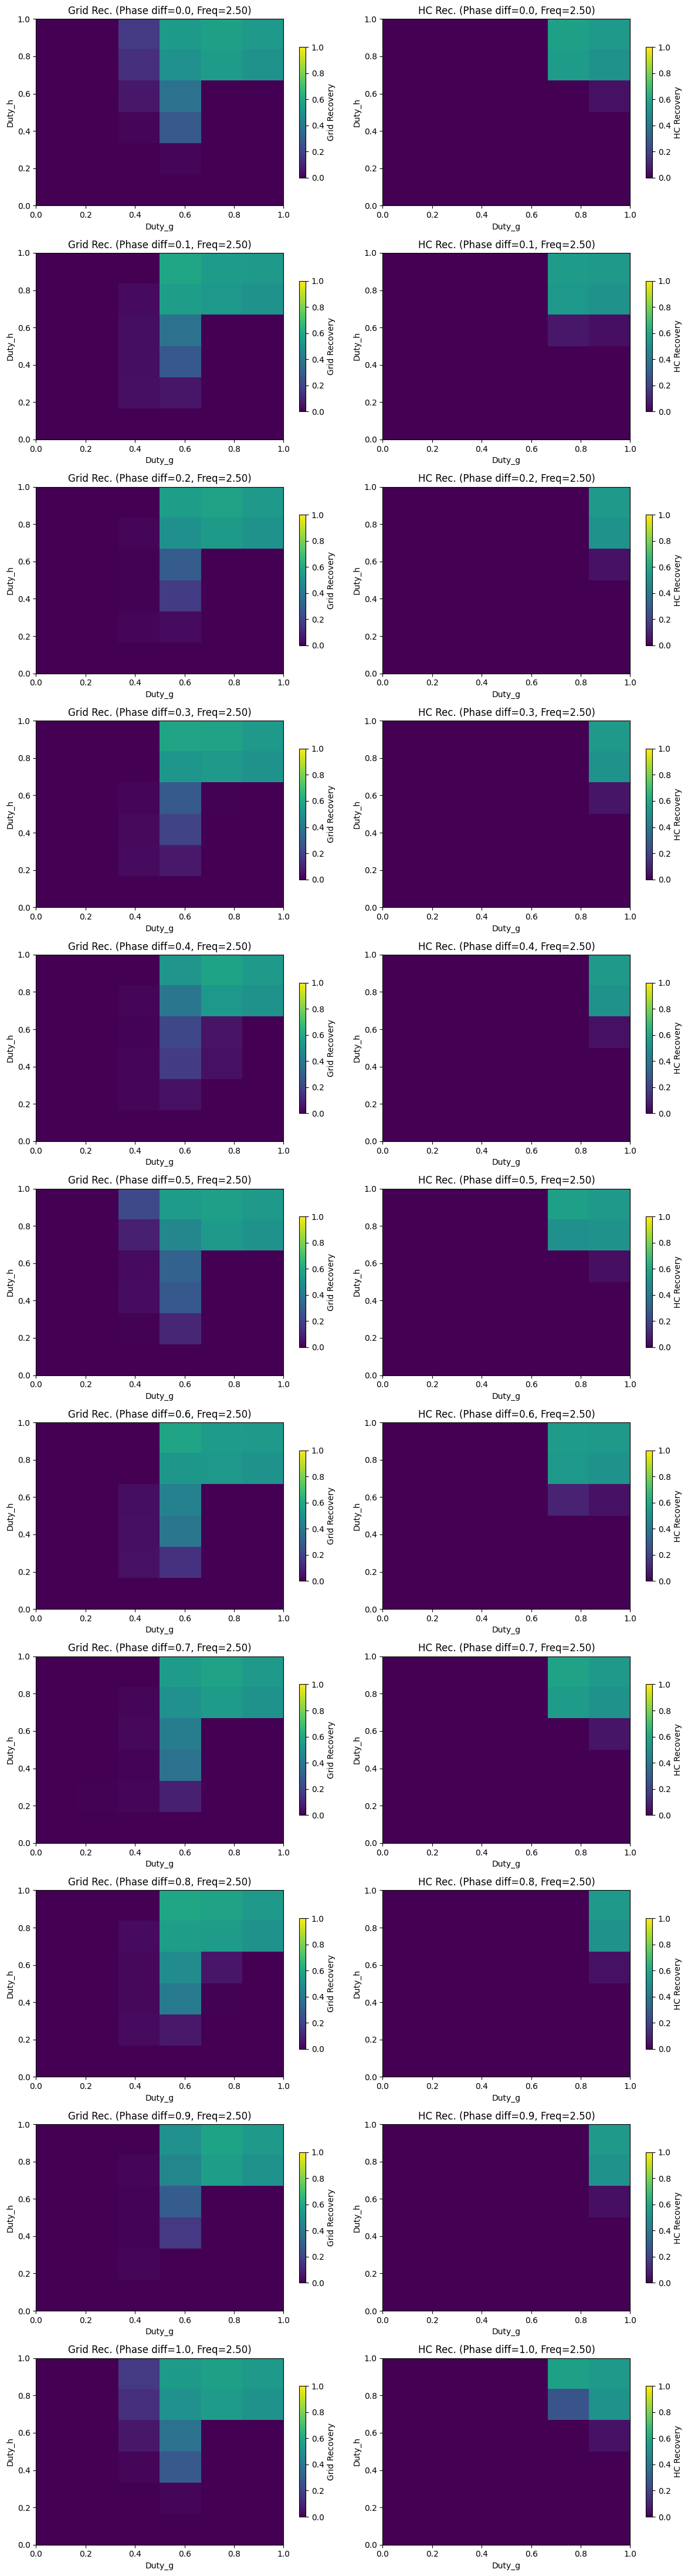

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Choose a specific common frequency value to visualize
# From freq_h_range: [0.  , 0.25, 0.5 , 0.75, 1.  , 1.25, 1.5 , 1.75, 2.  , 2.25, 2.5 , 2.75, 3.  , 3.25, 3.5 , 3.75]
# Let's pick 1.25 Hz (index 5)
f_common_idx = 10
f_common_val = freq_h_range[f_common_idx]

print(f"Generating heatmaps for common frequency: {f_common_val} Hz")

# Extract the 3D slice for the chosen common frequency where freq_h = freq_g = f_common_val
# The shape of frac_grid is (Fh, Fg, Dh, Dg, Pd)
# So, frac_grid[f_common_idx, f_common_idx, :, :, :] will give (Dh, Dg, Pd)
grid_for_fixed_freq = frac_grid[f_common_idx, f_common_idx, :, :, :]
hc_for_fixed_freq = frac_hc[f_common_idx, f_common_idx, :, :, :]

num_phases = len(phase_diff_range)

# Create a figure with a row for each phase difference, and two columns (grid and hc)
fig, axes = plt.subplots(num_phases, 2, figsize=(12, 4 * num_phases), squeeze=False)

for pd_idx, phase_diff_val in enumerate(phase_diff_range):
    # Extract 2D slice for current phase_diff (duty_h, duty_g)
    grid_heatmap_data = grid_for_fixed_freq[:, :, pd_idx]
    hc_heatmap_data = hc_for_fixed_freq[:, :, pd_idx]

    # Plot for Grid Recovery
    im0 = axes[pd_idx, 0].imshow(grid_heatmap_data, origin='lower', vmin=0, vmax=1,
                                 extent=[duty_g_range[0], duty_g_range[-1],
                                         duty_h_range[0], duty_h_range[-1]],
                                 aspect='auto', cmap='viridis')
    axes[pd_idx, 0].set_title(f'Grid Rec. (Phase diff={phase_diff_val:.1f}, Freq={f_common_val:.2f})')
    axes[pd_idx, 0].set_xlabel('Duty_g')
    axes[pd_idx, 0].set_ylabel('Duty_h')
    fig.colorbar(im0, ax=axes[pd_idx, 0], shrink=0.7, label='Grid Recovery')

    # Plot for HC Recovery
    im1 = axes[pd_idx, 1].imshow(hc_heatmap_data, origin='lower', vmin=0, vmax=1,
                                 extent=[duty_g_range[0], duty_g_range[-1],
                                         duty_h_range[0], duty_h_range[-1]],
                                 aspect='auto', cmap='viridis')
    axes[pd_idx, 1].set_title(f'HC Rec. (Phase diff={phase_diff_val:.1f}, Freq={f_common_val:.2f})')
    axes[pd_idx, 1].set_xlabel('Duty_g')
    axes[pd_idx, 1].set_ylabel('Duty_h')
    fig.colorbar(im1, ax=axes[pd_idx, 1], shrink=0.7, label='HC Recovery')

plt.tight_layout()
plt.show()

### Heatmaps of (Freq_h, Freq_g) for Fixed Duty Cycles

These heatmaps display the grid and head-direction cell recovery fractions for specific fixed duty cycles (`duty_h` = `0.6` and `duty_g` = `0.6`) across different combinations of `freq_h` and `freq_g`, separated by `phase_diff` values.


Fixed duty_h at 0.6 and duty_g at 0.6


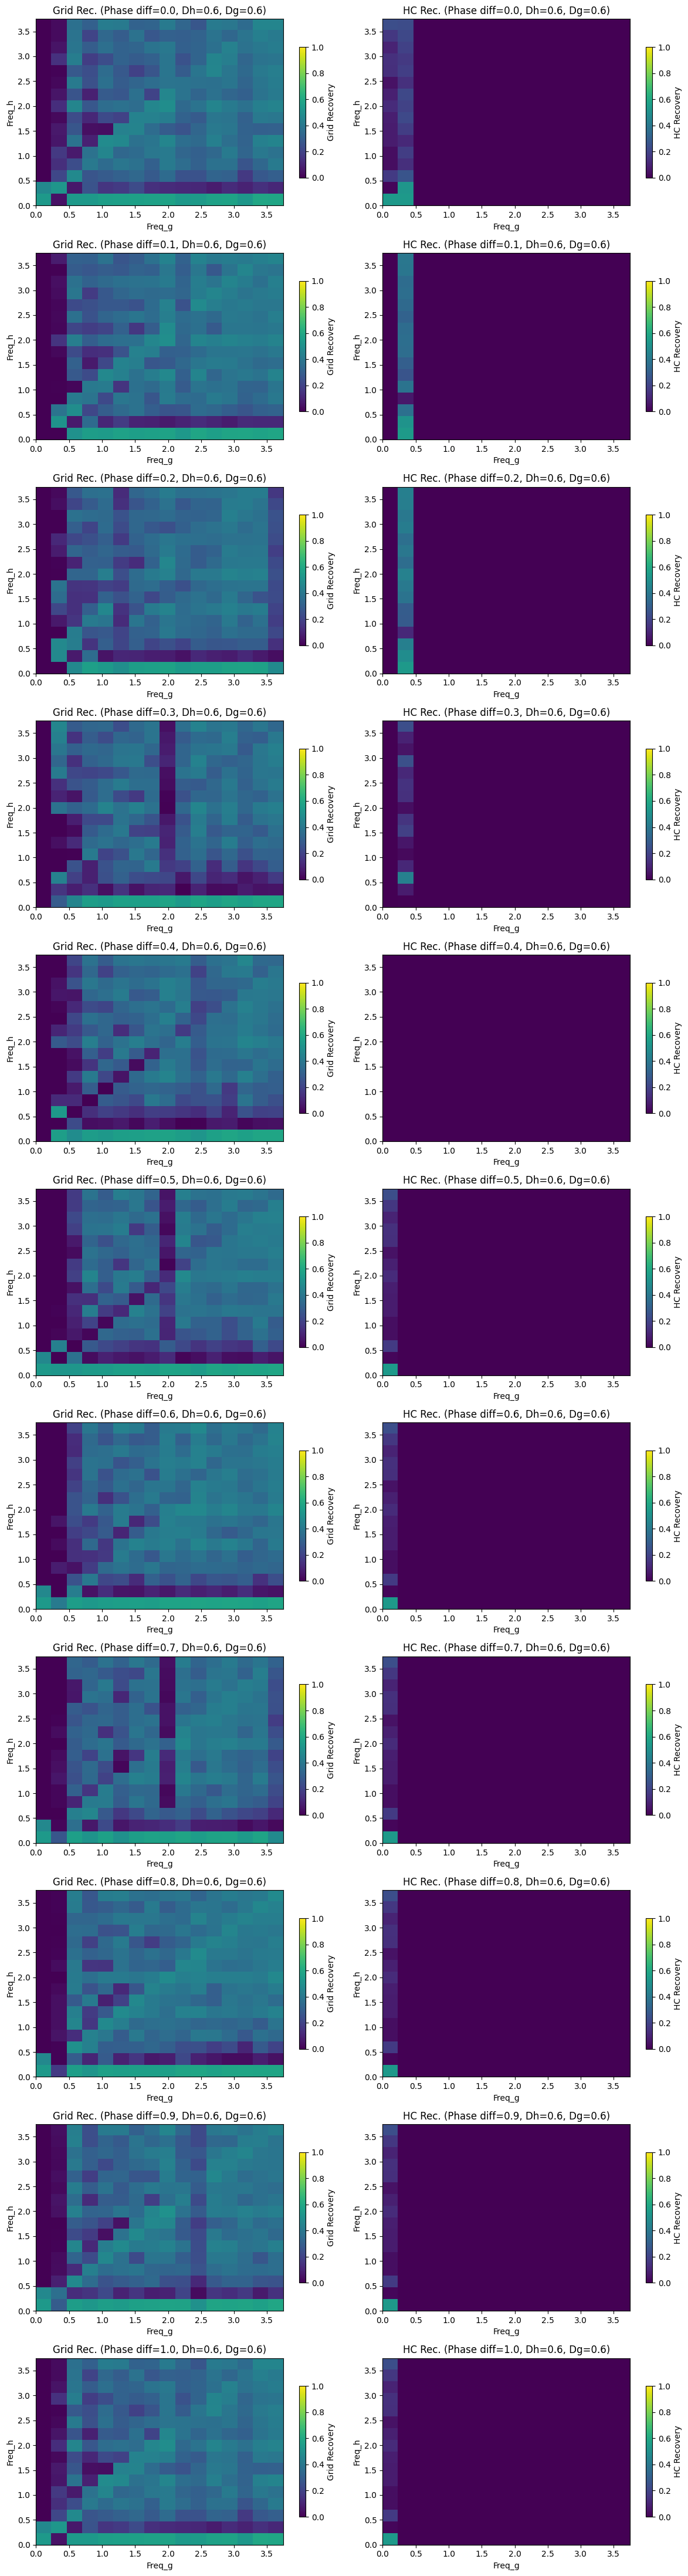

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Find the index for duty_h = 0.6
duty_h_idx = np.where(np.isclose(duty_h_range, 0.6))[0][0]
# Find the index for duty_g = 0.6
duty_g_idx = np.where(np.isclose(duty_g_range, 0.6))[0][0]

print(f"Fixed duty_h at {duty_h_range[duty_h_idx]:.1f} and duty_g at {duty_g_range[duty_g_idx]:.1f}")

# Extract the 3D slices for the chosen duty_h and duty_g values
# The shape of frac_grid is (Fh, Fg, Dh, Dg, Pd)
# So, frac_grid[:, :, duty_h_idx, duty_g_idx, :] will give (Fh, Fg, Pd)
grid_for_fixed_duties = frac_grid[:, :, duty_h_idx, duty_g_idx, :]
hc_for_fixed_duties = frac_hc[:, :, duty_h_idx, duty_g_idx, :]

num_phases = len(phase_diff_range)

# Create a figure with a row for each phase difference, and two columns (grid and hc)
fig, axes = plt.subplots(num_phases, 2, figsize=(12, 4 * num_phases), squeeze=False)

for pd_idx, phase_diff_val in enumerate(phase_diff_range):
    # Extract 2D slice for current phase_diff (freq_h, freq_g)
    grid_heatmap_data = grid_for_fixed_duties[:, :, pd_idx]
    hc_heatmap_data = hc_for_fixed_duties[:, :, pd_idx]

    # Plot for Grid Recovery
    im0 = axes[pd_idx, 0].imshow(grid_heatmap_data, origin='lower', vmin=0, vmax=1,
                                 extent=[freq_g_range[0], freq_g_range[-1],
                                         freq_h_range[0], freq_h_range[-1]],
                                 aspect='auto', cmap='viridis')
    axes[pd_idx, 0].set_title(f'Grid Rec. (Phase diff={phase_diff_val:.1f}, Dh={duty_h_range[duty_h_idx]:.1f}, Dg={duty_g_range[duty_g_idx]:.1f})')
    axes[pd_idx, 0].set_xlabel('Freq_g')
    axes[pd_idx, 0].set_ylabel('Freq_h')
    fig.colorbar(im0, ax=axes[pd_idx, 0], shrink=0.7, label='Grid Recovery')

    # Plot for HC Recovery
    im1 = axes[pd_idx, 1].imshow(hc_heatmap_data, origin='lower', vmin=0, vmax=1,
                                 extent=[freq_g_range[0], freq_g_range[-1],
                                         freq_h_range[0], freq_h_range[-1]],
                                 aspect='auto', cmap='viridis')
    axes[pd_idx, 1].set_title(f'HC Rec. (Phase diff={phase_diff_val:.1f}, Dh={duty_h_range[duty_h_idx]:.1f}, Dg={duty_g_range[duty_g_idx]:.1f})')
    axes[pd_idx, 1].set_xlabel('Freq_g')
    axes[pd_idx, 1].set_ylabel('Freq_h')
    fig.colorbar(im1, ax=axes[pd_idx, 1], shrink=0.7, label='HC Recovery')

plt.tight_layout()
plt.show()

## 2D Searches

In [ ]:
freq_range = np.arange(0.0, 1.5, 0.05)
duty_range = np.array(0.5)
phase_diff_range = np.arange(0.0, 1.1, 0.1)
phase_h = 0.0

frac_grid, frac_hc = parameter_search_scored(
    scaffold, g0_init, h0, g0_target, h0, h0_norm,
    freq_range, freq_range, duty_range, duty_range, phase_diff_range,
    phase_h=phase_h,
    n_steps=250, chunk_size=500, grid_thresh=0.3
)

np.save('frac_grid_output.npy', frac_grid)
np.save('frac_hc_output.npy', frac_hc)

# frac_grid_output: (Fh, Fg, Dh, Dg, Pd), frac_hc_output: (Fh, Fg, Dh, Dg, Pd)
print(frac_grid.shape, frac_hc.shape)

100%|██████████| 20/20 [06:23<00:00, 19.17s/it]

(30, 30, 1, 1, 11) (30, 30, 1, 1, 11)


(30, 30, 11) (30, 30, 11)
False


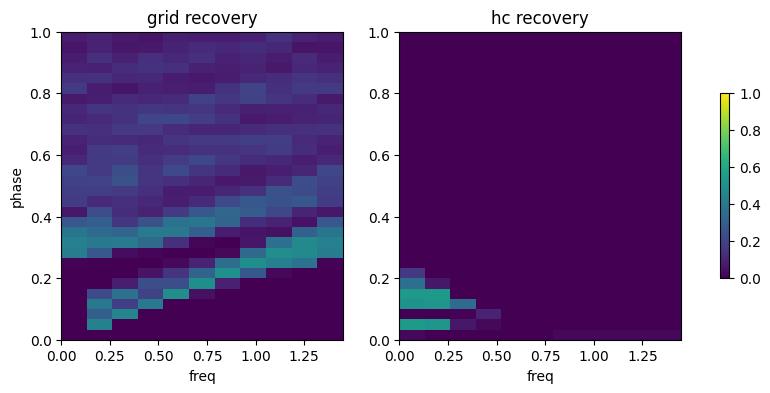

In [ ]:
frac_grid = np.squeeze(frac_grid)
frac_hc = np.squeeze(frac_hc)
print(frac_grid.shape, frac_hc.shape)
#print(frac_grid[1, :, :], frac_grid[:, 1, :])
print(np.allclose(frac_grid[:, 1, :], frac_grid[:, 12, :]))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im0 = ax[0].imshow(frac_grid[8], origin='lower', vmin=0, vmax=1,
                    extent=[freq_range[0], freq_range[-1], phase_diff_range[0], phase_diff_range[-1]], aspect='auto')
ax[0].set_xlabel('freq'); ax[0].set_ylabel('phase'); ax[0].set_title('grid recovery')
im1 = ax[1].imshow(frac_hc[1], origin='lower', vmin=0, vmax=1,
                    extent=[freq_range[0], freq_range[-1], phase_diff_range[0], phase_diff_range[-1]], aspect='auto')
ax[1].set_xlabel('freq'); ax[1].set_title('hc recovery')
fig.colorbar(im1, ax=ax, shrink=0.6)

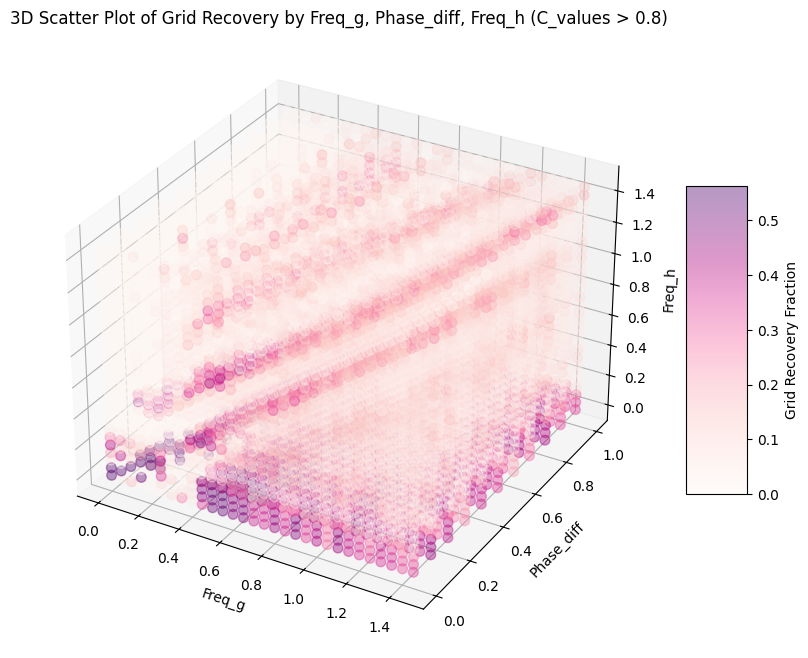

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create flattened arrays for X, Y, Z (axes) and C (color)
X_coords_all = [] # Freq_g
Y_coords_all = [] # Phase_diff
Z_coords_all = [] # Freq_h
C_values_all = [] # frac_grid

# Note: freq_range is used for both freq_h and freq_g in the parameter search
# so freq_h_range and freq_g_range from parameter_search_scored are both freq_range here.
for fh_idx, fh_val in enumerate(freq_range): # Iterate through freq_h values (Z-axis)
    for fg_idx, fg_val in enumerate(freq_range): # Iterate through freq_g values (X-axis)
        for pd_idx, pd_val in enumerate(phase_diff_range): # Iterate through phase_diff values (Y-axis)
            X_coords_all.append(fg_val)
            Y_coords_all.append(pd_val)
            Z_coords_all.append(fh_val)
            # frac_grid is (len(freq_h_range), len(freq_g_range), len(phase_diff_range))
            # The original `parameter_search_scored` used `freq_range` for both `freq_h_vals` and `freq_g_vals`
            # so, fh_idx corresponds to the first dimension, fg_idx to the second, and pd_idx to the third.
            C_values_all.append(frac_grid[fh_idx, fg_idx, pd_idx])

X_coords_all = np.array(X_coords_all)
Y_coords_all = np.array(Y_coords_all)
Z_coords_all = np.array(Z_coords_all)
C_values_all = np.array(C_values_all)

# Filter for high recovery values
"""high_recovery_mask = C_values_all > 0.5
X_coords = X_coords_all[high_recovery_mask]
Y_coords = Y_coords_all[high_recovery_mask]
Z_coords = Z_coords_all[high_recovery_mask]
C_values = C_values_all[high_recovery_mask]"""

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the scatter points
scatter = ax.scatter(X_coords_all, Y_coords_all, Z_coords_all, c=C_values_all, cmap='RdPu', s=50, alpha=0.4)

ax.set_xlabel('Freq_g')
ax.set_ylabel('Phase_diff')
ax.set_zlabel('Freq_h') # Z-label remains Freq_h
ax.set_title('3D Scatter Plot of Grid Recovery by Freq_g, Phase_diff, Freq_h (C_values > 0.8)') # Updated title

fig.colorbar(scatter, shrink=0.5, aspect=5, label='Grid Recovery Fraction') # Updated color bar label
plt.show()

### Parameter Search with `freq_h` = `freq_g`



In [ ]:
common_freq_range = np.arange(0.0, 2.5, 0.1)
duty_h_vals = np.array([0.5])
duty_g_vals = np.array([0.5])
phase_diff_range = np.arange(0.0, 1.1, 0.1)
phase_h = 0.0

all_frac_grid_results = []
all_frac_hc_results = []

for f_common in tqdm(common_freq_range, desc="Common Frequency Search"):
    frac_grid_slice, frac_hc_slice = parameter_search_scored(
        scaffold, g0_init, h0, g0_target, h0, h0_norm,
        np.array([f_common]), np.array([f_common]),
        duty_h_vals, duty_g_vals, phase_diff_range,
        phase_h=phase_h,
        n_steps=250, grid_thresh=0.3, chunk_size=500, show_progress=False
    )
    all_frac_grid_results.append(frac_grid_slice)
    all_frac_hc_results.append(frac_hc_slice)


frac_grid_common_freq = np.concatenate(all_frac_grid_results, axis=0)
frac_hc_common_freq = np.concatenate(all_frac_hc_results, axis=0)
frac_grid_common_freq = np.squeeze(frac_grid_common_freq)
frac_hc_common_freq = np.squeeze(frac_hc_common_freq)

print(f"\nShape of frac_grid_common_freq: {frac_grid_common_freq.shape}")
print(f"Shape of frac_hc_common_freq: {frac_hc_common_freq.shape}")

Common Frequency Search: 100%|██████████| 25/25 [00:22<00:00,  1.10it/s]


Shape of frac_grid_common_freq: (25, 11)
Shape of frac_hc_common_freq: (25, 11)


In [ ]:
flat_idx_grid = np.argmax(frac_grid_common_freq)
coords_grid = np.unravel_index(flat_idx_grid, frac_grid_common_freq.shape)
print(f"\nMax grid: {frac_grid_common_freq[coords_grid]} at indices {coords_grid}")
print(common_freq_range[coords_grid[0]], phase_diff_range[coords_grid[1]])

flat_idx_hc = np.argmax(frac_hc_common_freq)
coords_hc = np.unravel_index(flat_idx_hc, frac_hc_common_freq.shape)
print(f"\nMax hc: {frac_hc_common_freq[coords_grid]} at indices {coords_hc}")
print(common_freq_range[coords_hc[0]], phase_diff_range[coords_hc[1]])


Max grid: 0.5550000071525574 at indices (np.int64(1), np.int64(1))
0.1 0.1

Max hc: 0.5550000071525574 at indices (np.int64(1), np.int64(1))
0.1 0.1


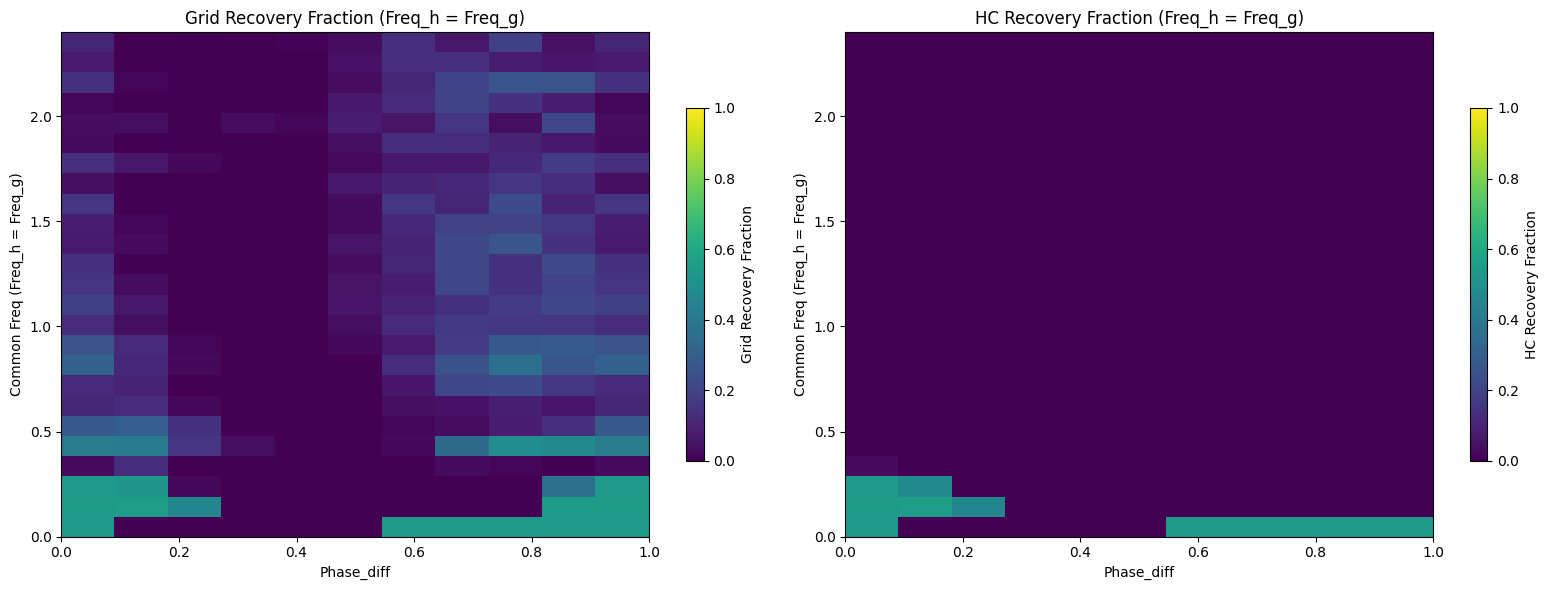

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap for frac_grid_common_freq
im0 = ax[0].imshow(frac_grid_common_freq, origin='lower', vmin=0, vmax=1,
                   extent=[phase_diff_range[0], phase_diff_range[-1],
                           common_freq_range[0], common_freq_range[-1]],
                   aspect='auto', cmap='viridis')
ax[0].set_xlabel('Phase_diff')
ax[0].set_ylabel('Common Freq (Freq_h = Freq_g)')
ax[0].set_title('Grid Recovery Fraction (Freq_h = Freq_g)')
fig.colorbar(im0, ax=ax[0], shrink=0.7, label='Grid Recovery Fraction')

# Heatmap for frac_hc_common_freq
im1 = ax[1].imshow(frac_hc_common_freq, origin='lower', vmin=0, vmax=1,
                   extent=[phase_diff_range[0], phase_diff_range[-1],
                           common_freq_range[0], common_freq_range[-1]],
                   aspect='auto', cmap='viridis')
ax[1].set_xlabel('Phase_diff')
ax[1].set_ylabel('Common Freq (Freq_h = Freq_g)')
ax[1].set_title('HC Recovery Fraction (Freq_h = Freq_g)')
fig.colorbar(im1, ax=ax[1], shrink=0.7, label='HC Recovery Fraction')

plt.tight_layout()
plt.show()

#